# So sanh hieu nang cac mo hinh Lab 03

In [1]:
import os
import sys
import time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support
from dataset import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_root = "./dataset/UCF50"
train_loader, val_loader, class_to_idx = get_dataloaders(
    data_root=data_root,
    batch_size=32,
    num_frames=16,
    img_size=112,
    output_format="CTHW",
    split_ratio=0.8,
    num_workers=4,
    seed=42
)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

models_config = [
    {"name": "3D CNN Baseline", "module": "cnn3d", "class": "SimpleCNN3D", "ckpt": "best_cnn3d.pth"},
    {"name": "3D CNN v2 (5x5)", "module": "cnn3d_v2", "class": "SimpleCNN3D_v2", "ckpt": "best_cnn3d_v2.pth"},
    {"name": "3D CNN Sequential", "module": "cnn3d_sequential", "class": "SimpleCNN3D_Sequential", "ckpt": "best_cnn3d_sequential.pth"},
    {"name": "MobileNetV4 + GRU", "module": "mobilenetv4_gru", "class": "MobileNetV4_GRU", "ckpt": "best_mobilenetv4_gru.pth"}
]

benchmark_results = []
dummy = torch.randn(1, 3, 16, 112, 112, device=device)
dummy_batch = torch.randn(32, 3, 16, 112, 112, device=device)

for cfg in models_config:
    mod = importlib.import_module(cfg["module"])
    cls = getattr(mod, cfg["class"])
    model = cls(num_classes=len(class_names)).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    file_size_mb = os.path.getsize(cfg["ckpt"]) / (1024 * 1024)

    ckpt = torch.load(cfg["ckpt"], map_location=device)
    state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    clean_state = {(k[7:] if k.startswith("module.") else k): v for k, v in state_dict.items()}
    model.load_state_dict(clean_state)
    model.eval()

    with torch.no_grad():
        for _ in range(15):
            with torch.amp.autocast("cuda"):
                _ = model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    trials = 60
    latencies = []
    with torch.no_grad():
        for _ in range(trials):
            t0 = time.perf_counter()
            with torch.amp.autocast("cuda"):
                _ = model(dummy)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000.0)

    mean_lat = float(np.mean(latencies))
    std_lat = float(np.std(latencies))
    p95_lat = float(np.percentile(latencies, 95))
    throughput_fps = 1000.0 / mean_lat

    batch_trials = 20
    batch_latencies = []
    with torch.no_grad():
        for _ in range(batch_trials):
            t0 = time.perf_counter()
            with torch.amp.autocast("cuda"):
                _ = model(dummy_batch)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            batch_latencies.append((time.perf_counter() - t0) * 1000.0)
    mean_batch_lat = float(np.mean(batch_latencies))

    top1_correct, top5_correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    eval_t0 = time.time()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast("cuda"):
                logits = model(x)
            probs = F.softmax(logits, dim=1)
            _, pred = torch.max(probs, dim=1)
            _, top5 = torch.topk(probs, k=5, dim=1)

            top1_correct += (pred == y).sum().item()
            top5_correct += (top5 == y.unsqueeze(1)).sum().item()
            total += y.size(0)

            all_preds.extend(pred.cpu().numpy().tolist())
            all_targets.extend(y.cpu().numpy().tolist())

    total_eval_time = time.time() - eval_t0
    avg_batch_eval_time_ms = (total_eval_time / len(val_loader)) * 1000.0

    top1_acc = (top1_correct / total) * 100.0
    top5_acc = (top5_correct / total) * 100.0
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(all_targets, all_preds, average="macro", zero_division=0)

    benchmark_results.append({
        "Model": cfg["name"],
        "Params": total_params,
        "Size (MB)": round(file_size_mb, 2),
        "Mean Latency (ms)": round(mean_lat, 2),
        "Std Latency (ms)": round(std_lat, 2),
        "P95 Latency (ms)": round(p95_lat, 2),
        "Batch Latency (ms)": round(mean_batch_lat, 2),
        "Avg Eval Batch (ms)": round(avg_batch_eval_time_ms, 2),
        "FPS": round(throughput_fps, 1),
        "Top-1 Acc (%)": round(top1_acc, 2),
        "Top-5 Acc (%)": round(top5_acc, 2),
        "Macro F1": round(f1_macro, 4)
    })
    print(f"Evaluated {cfg['name']}: Top-1={top1_acc:.2f}%, Latency={mean_lat:.2f}ms")

df = pd.DataFrame(benchmark_results)
display(df)


Device: cuda


Evaluated 3D CNN Baseline: Top-1=74.61%, Latency=1.47ms


Evaluated 3D CNN v2 (5x5): Top-1=78.01%, Latency=3.04ms


Evaluated 3D CNN Sequential: Top-1=81.40%, Latency=1.15ms


/workspace/Advanced-Reading-On-Computer-Vision/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Evaluated MobileNetV4 + GRU: Top-1=97.86%, Latency=4.45ms


,Model,Params,Size (MB),Mean Latency (ms),Std Latency (ms),P95 Latency (ms),Batch Latency (ms),Avg Eval Batch (ms),FPS,Top-1 Acc (%),Top-5 Acc (%),Macro F1
0,3D CNN Baseline,62462,0.25,1.47,0.01,1.48,41.76,198.73,680.3,74.61,94.91,0.7397
1,3D CNN v2 (5x5),96254,0.38,3.04,0.04,3.05,90.31,206.81,328.9,78.01,95.35,0.7721
2,3D CNN Sequential,102562,1.19,1.15,0.00,1.16,32.03,199.19,867.0,81.40,96.38,0.8098
3,MobileNetV4 + GRU,9918610,113.86,4.45,0.32,4.47,28.41,195.69,224.9,97.86,99.70,0.9784


**Nhận xét:**

Bảng số liệu tổng hợp phản ánh rõ ưu thế và sự đánh đổi giữa các kiến trúc. Các mô hình 3D CNN sở hữu cấu trúc gọn nhẹ và độ trễ thấp, trong khi mô hình kết hợp mạng 2D cùng mạng hồi quy mang lại độ chính xác vượt trội nhất.

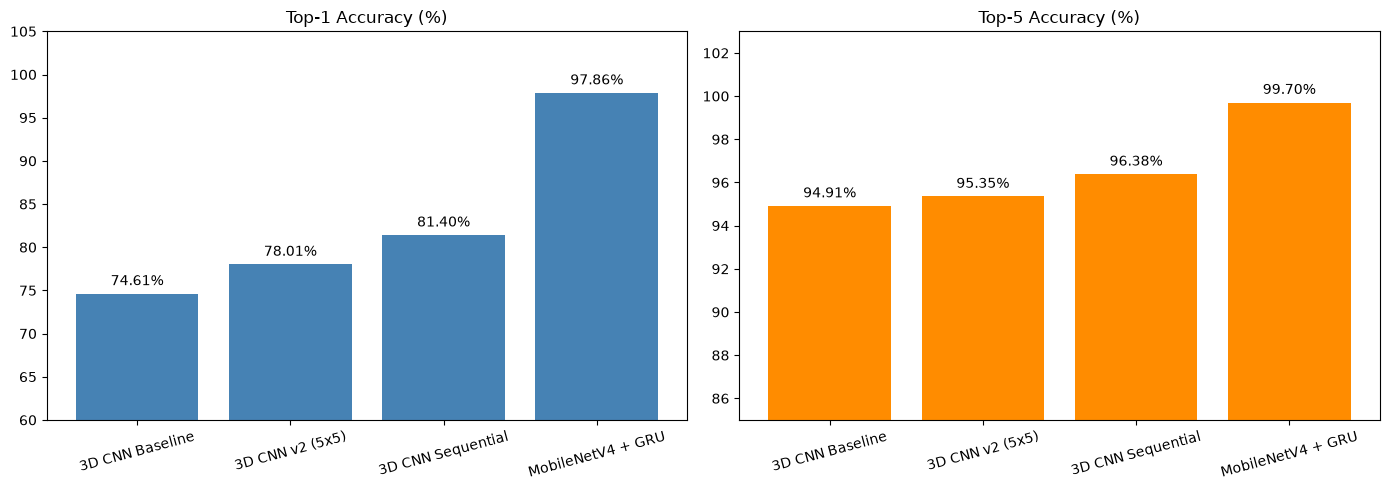

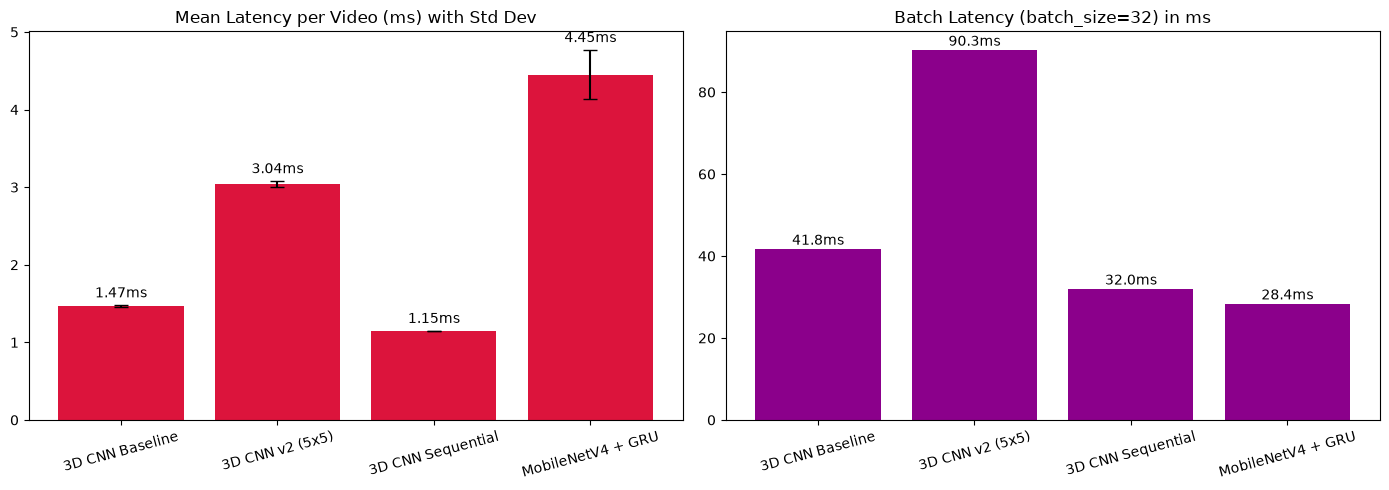

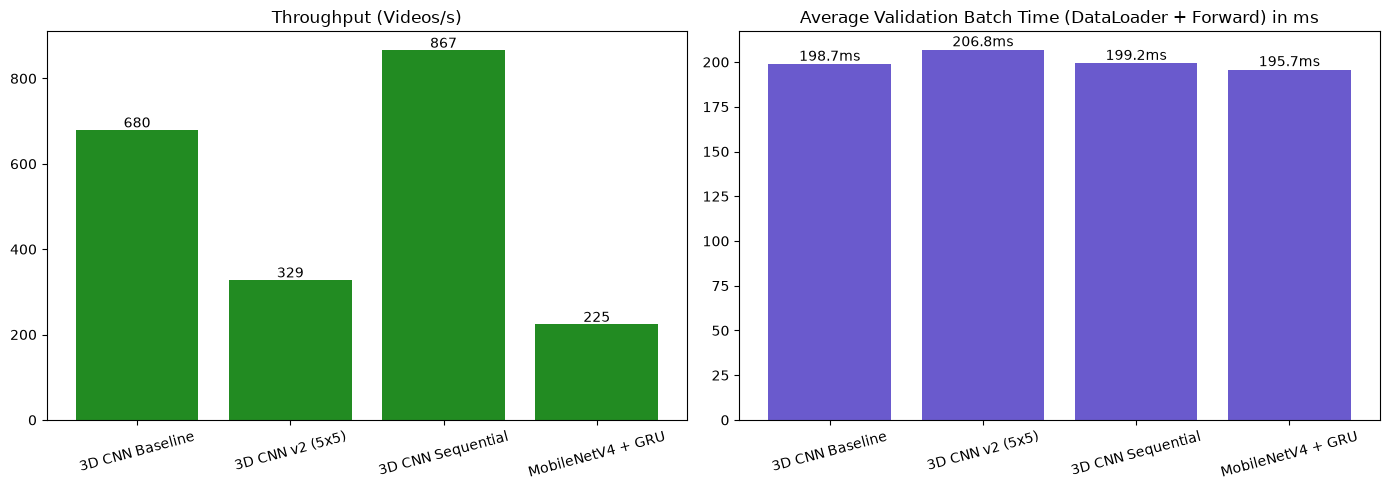

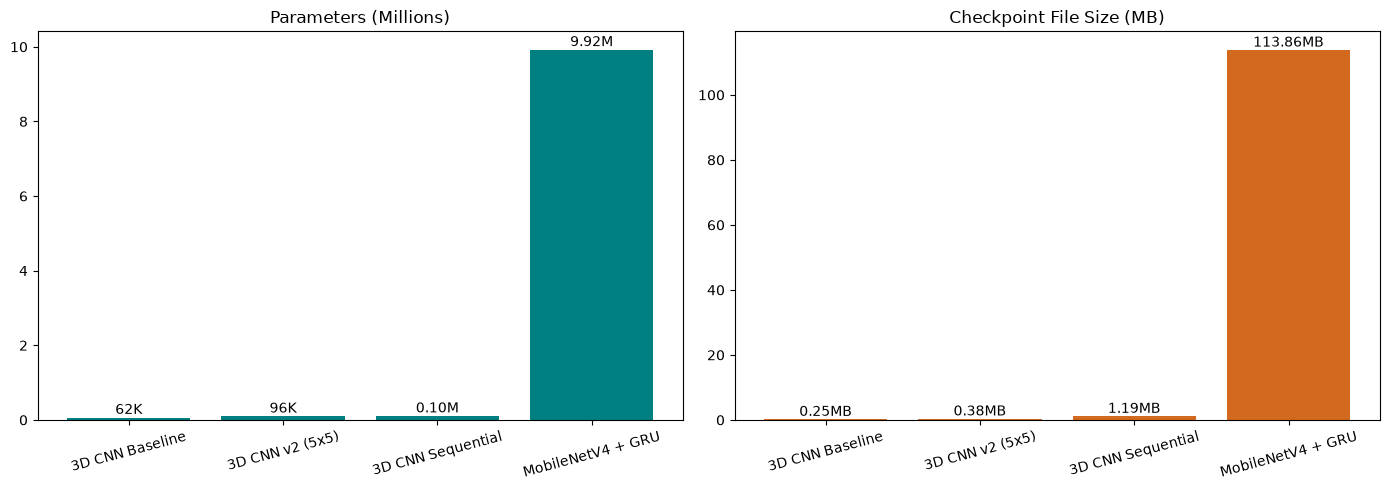

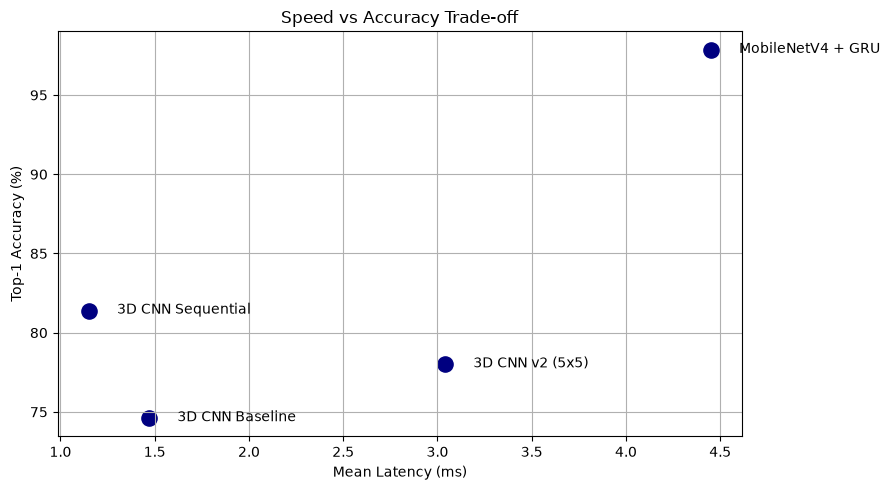

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df["Model"], df["Top-1 Acc (%)"], color="steelblue")
axes[0].set_title("Top-1 Accuracy (%)")
axes[0].set_ylim(60, 105)
for i, v in enumerate(df["Top-1 Acc (%)"]):
    axes[0].text(i, v + 1, f"{v:.2f}%", ha="center")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(df["Model"], df["Top-5 Acc (%)"], color="darkorange")
axes[1].set_title("Top-5 Accuracy (%)")
axes[1].set_ylim(85, 103)
for i, v in enumerate(df["Top-5 Acc (%)"]):
    axes[1].text(i, v + 0.4, f"{v:.2f}%", ha="center")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df["Model"], df["Mean Latency (ms)"], yerr=df["Std Latency (ms)"], capsize=5, color="crimson")
axes[0].set_title("Mean Latency per Video (ms) with Std Dev")
for i, v in enumerate(df["Mean Latency (ms)"]):
    axes[0].text(i, v + df["Std Latency (ms)"][i] + 0.1, f"{v:.2f}ms", ha="center")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(df["Model"], df["Batch Latency (ms)"], color="darkmagenta")
axes[1].set_title("Batch Latency (batch_size=32) in ms")
for i, v in enumerate(df["Batch Latency (ms)"]):
    axes[1].text(i, v + 1, f"{v:.1f}ms", ha="center")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df["Model"], df["FPS"], color="forestgreen")
axes[0].set_title("Throughput (Videos/s)")
for i, v in enumerate(df["FPS"]):
    axes[0].text(i, v + 5, f"{v:.0f}", ha="center")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(df["Model"], df["Avg Eval Batch (ms)"], color="slateblue")
axes[1].set_title("Average Validation Batch Time (DataLoader + Forward) in ms")
for i, v in enumerate(df["Avg Eval Batch (ms)"]):
    axes[1].text(i, v + 2, f"{v:.1f}ms", ha="center")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df["Model"], df["Params"] / 1e6, color="teal")
axes[0].set_title("Parameters (Millions)")
for i, v in enumerate(df["Params"] / 1e6):
    axes[0].text(i, v + 0.1, f"{v:.2f}M" if v >= 0.1 else f"{v*1000:.0f}K", ha="center")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(df["Model"], df["Size (MB)"], color="chocolate")
axes[1].set_title("Checkpoint File Size (MB)")
for i, v in enumerate(df["Size (MB)"]):
    axes[1].text(i, v + 1, f"{v:.2f}MB", ha="center")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(df["Mean Latency (ms)"], df["Top-1 Acc (%)"], s=120, color="navy")
for i, row in df.iterrows():
    plt.annotate(row["Model"], (row["Mean Latency (ms)"] + 0.15, row["Top-1 Acc (%)"] - 0.2))
plt.title("Speed vs Accuracy Trade-off")
plt.xlabel("Mean Latency (ms)")
plt.ylabel("Top-1 Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


**Nhận xét:**

Các mô hình 3D CNN tự huấn luyện từ đầu có ưu điểm là kiến trúc nhẹ và xử lý trực tiếp dữ liệu dạng khối, nhưng thường cần lượng dữ liệu lớn hơn nhiều để đạt kết quả thật cao.

Ngược lại các hướng tiếp cận kết hợp như luồng chuyển động quang học hoặc mạng tích chập kết hợp mạng hồi quy cho hiệu năng vượt trội hơn hẳn nhờ khai thác được các đặc trưng đã học sẵn và tách biệt rõ ràng giữa hình ảnh tĩnh và chuyển động. Tùy theo bài toán thực tế và phần cứng triển khai để lựa chọn mô hình cân bằng giữa độ chính xác và tài nguyên máy tính.